In [1]:
import pandas as pd
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import matplotlib.pyplot as plt
from remove_col import preprocees_dataset
from chat import bar_chart_view, flirt_chat, group_chart
from word_cloud_image_generate import create_wordcloud_image
from chat_flirting_data import get_flirt_label, filer_encounter, time_encounter

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

In [ ]:
df = pd.read_csv(
    "group.txt",
    header=None,
    on_bad_lines="skip",
    encoding="utf-8"
)
df

In [ ]:
data = preprocees_dataset(df, [0], [2,3])

# Remove unwanted Specific Row
data = data[
    data["Chat"].astype(str).str.strip().ne("<Media omitted>")
].reset_index(drop=True)

data = data[
    data["Chat"].astype(str).str.strip().ne(". <This message was edited>")
].reset_index(drop=True)

data = data[
    data["Chat"].notna()
    & data["Chat"].astype(str).str.strip().ne("")
].reset_index(drop=True)

data = data[
    data["Chat"].notna()
    & data["Chat"].astype(str).str.strip().ne("{")
].reset_index(drop=True)

# Date Column Check
date_text = data["Date"].astype("string").str.strip()

valid_date = (
    date_text.str.fullmatch(r"\d{2}/\d{2}/\d{2}", na=False)
    & pd.to_datetime(date_text, format="%d/%m/%y", errors="coerce").notna()
)

data = data.loc[valid_date].reset_index(drop=True)

data = data[
    data["Chat"].astype(str).str.strip().ne("Today EOD")
].reset_index(drop=True)

data = data[
    data["Chat"].astype(str).str.strip().ne("today eod")
].reset_index(drop=True)

data = data[
    data["Chat"].astype(str).str.strip().ne("today eod")
].reset_index(drop=True)

data = data.drop(
    data[
        data["Chat"].str.contains(r"\bEOD\b", case=False, na=False)
    ].index
).reset_index(drop=True)

data = data.drop(
    data[
        data["Chat"].str.contains(r"@all\s+join\b", case=False, na=False)
    ].index
).reset_index(drop=True)

In [ ]:
# Remove null value rows
data.dropna(inplace=True)

# SentimentIntensityAnalyzer Model from nltk
sid = SentimentIntensityAnalyzer()

# Get overall score pos, neg, neu and compound
data["Scores"] = data["Chat"].apply(lambda commentText: sid.polarity_scores(commentText))

# lambda function is using for For loop condition
# Get only compound score value
data["Compound"] = data["Scores"].apply(lambda compound_score: compound_score["compound"])
# Get only positive score value
data["Positive"] = data["Scores"].apply(lambda pos_score: pos_score["pos"])
# Get only negative score value
data["Negative"] = data["Scores"].apply(lambda neg_score: neg_score["neg"])
# Get only neutral score value
data["Neutral"] = data["Scores"].apply(lambda neu_score: neu_score["neu"])

In [ ]:
# Add every row chat value positive or negative or neutral
data["Status"] = data["Scores"].apply(
    lambda score: max(
        {"Negative": score["neg"], "Neutral": score["neu"], "Positive": score["pos"]},
        key=lambda sentiment: {
            "Negative": score["neg"],
            "Neutral": score["neu"],
            "Positive": score["pos"]
        }[sentiment]
    )
)

In [ ]:
# Finally we can get the conversation positive or negative or neutral
overall_sentiment = data["Status"].value_counts().idxmax()

print(f"This chat is {overall_sentiment}")

In [ ]:
# Want to save that CSV file use this command 
data.to_csv("group_final_data.csv", index=False)

In [ ]:
bar_chart_view(data, "Name", (12,8), "bar", "Message Count by Name", "Name", "Message Count")
bar_chart_view(data, "Status", (6,6), "pie", "Percentage View", "Status", "Status Count")


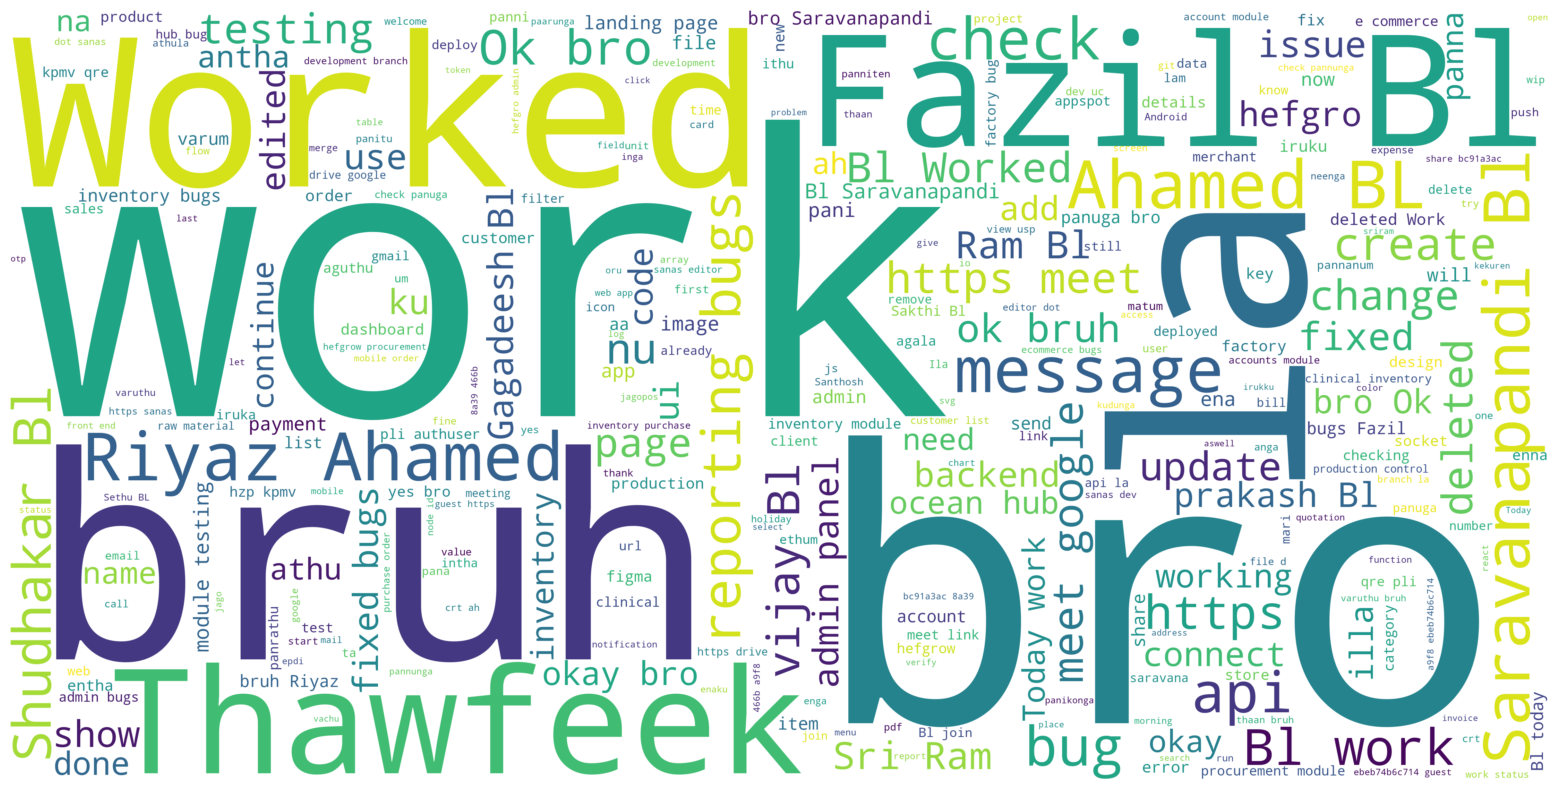

In [2]:
# Example text_color_map
# colormap="viridis"   # Blue, green, yellow
# colormap="plasma"    # Purple, red, yellow
# colormap="inferno"   # Black, red, yellow
# colormap="magma"     # Black, purple, white
# colormap="cool"      # Cyan and pink
# colormap="hot"       # Black, red, yellow, white
# colormap="spring"    # Pink and yellow
# colormap="summer"    # Green and yellow
# colormap="autumn"    # Red, orange, yellow
# colormap="winter"    # Blue and green
# colormap="rainbow"   # Rainbow colors
# colormap="tab10"     # Ten distinct colors
# colormap="Set2"      # Soft colors
# colormap="Dark2"     # Dark colors
# colormap="Pastel1"   # Pastel colors
# colormap="Blues"     # Different blue shades
# colormap="Reds"      # Different red shades
# colormap="Greens"    # Different green shades

dataset = pd.read_csv("group_final_data.csv")

# Join the all the chat
text = " ".join(dataset["Chat"].dropna().astype(str))

# Default Parameter
params = {
    "generate_text": text,
    "image_width": 2400,
    "image_height": 1200,
    "img_background_color": "white",
    "text_color_map": "viridis",
    "max_words": 300,
    "scale": 2,
    "file_name": "group_chat_wordcloud",
    "figsize": (20, 10)
}

create_wordcloud_image(params)


In [ ]:
# get flirt status
result= get_flirt_label(dataset, "Chat")

In [ ]:
results = result
labels, scores = zip(*results)


In [ ]:
dataset["Flirt_lable"] = labels
dataset["Flirt_Score"] = scores


In [ ]:
flirt_percentage_chat = flirt_chat(dataset, "Name", "Flirt_lable", "Flirting", "Flirting Percentage by Person", "Person", "Flirting Percentage", (15,8))

flirt_percentage_chat = flirt_chat(dataset, "Name", "Flirt_lable", "Friendly", "Friendly Percentage by Person", "Person", "Friendly Percentage", (15,8))


In [ ]:
# Filter encounder
talk_active, talk_less, eachperson = filer_encounter(dataset, "Name", "Flirt_lable", "Flirting")

print("Talk Active:", talk_active)
print("Less TalkActive:", talk_less)
print("Flirt Percentage by:", eachperson)

# highest = max(

#     eachperson,

#     key=lambda x: float(x.split(":")[-1].replace("%", ""))

# )

# print("Highest flirt:", highest)

In [ ]:
# Time encounder
active_date, active_day, active_hours, average_message_per_day = time_encounter(dataset, "Date", "Time")

print("Most Active Date:", active_date)
print("Most Active Day:", active_day)
print("Most Active Hour:", active_hours)
print("Average message per day:", average_message_per_day)


In [ ]:
# Want to save that CSV file use this command 
dataset.to_csv("group_final_data.csv", index=False)

/Users/thawfeek/Downloads/Ai-Course/Python/Small-Predection-Projects/chat-analyis/chat.py:51: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dataset[date_column_name] = pd.to_datetime(dataset[date_column_name], dayfirst=True)


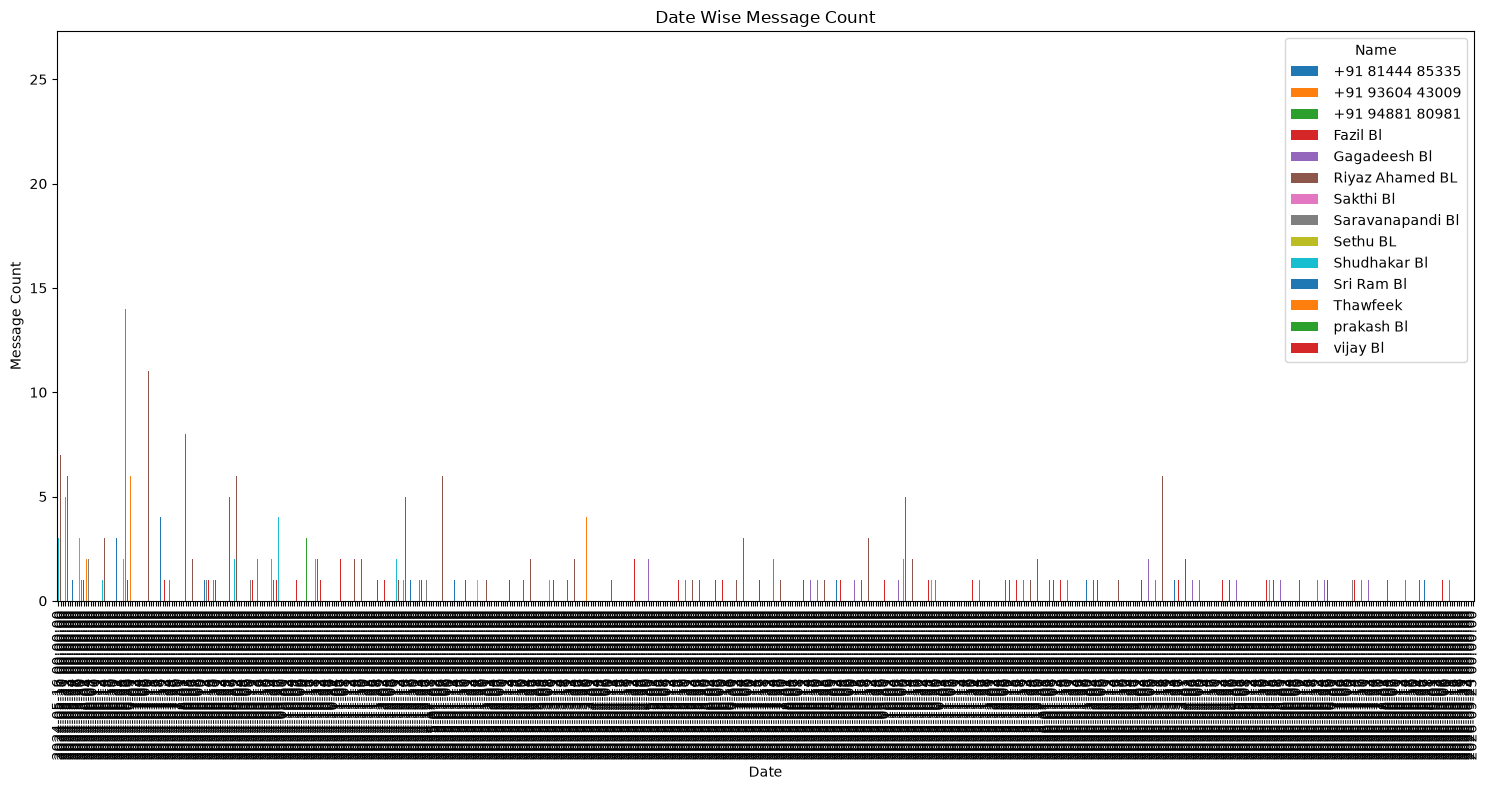

In [3]:
group_chart(dataset, "Date", "Name", "Date Wise Message Count","Date", "Message Count")